# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


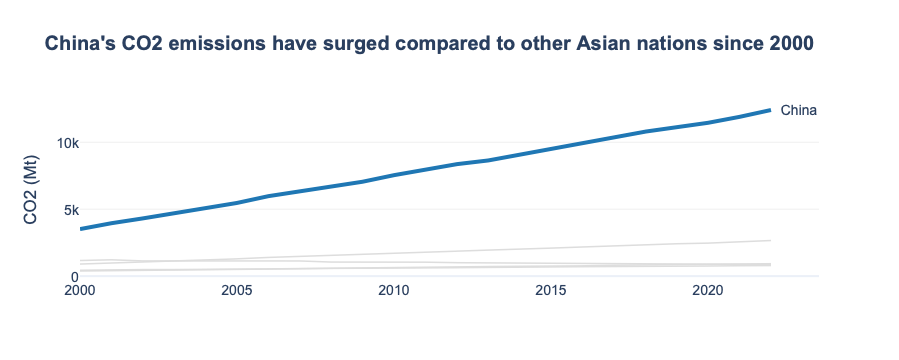

In [3]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE
import pandas as pd
import plotly.graph_objects as go

df_asia = df[df['Region'] == 'Asia']
highlight_country = 'China'

fig = go.Figure()

for country in df_asia['Country'].unique():
    df_c = df_asia[df_asia['Country'] == country]
    
    if country == highlight_country:
        color = '#1f77b4' # Bold Blue
        width = 4
        show_label = True
    else:
        color = '#DDDDDD' # Soft Grey
        width = 1.5
        show_label = False
        
    fig.add_trace(go.Scatter(
        x=df_c['Year'], 
        y=df_c['CO2_Mt'],
        mode='lines',
        name=country,
        line=dict(color=color, width=width),
        hoverinfo='name+y',
        showlegend=False
    ))

    if show_label:
        fig.add_annotation(
            x=df_c['Year'].iloc[-1], 
            y=df_c['CO2_Mt'].iloc[-1],
            text=f"  {country}",
            showarrow=False,
            xanchor='left'
        )

fig.update_layout(
    title="<b>China's CO2 emissions have surged compared to other Asian nations since 2000</b>",
    template='plotly_white',
    font=dict(family="Arial", size=14),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor='#F0F0F0', title="CO2 (Mt)")
)

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


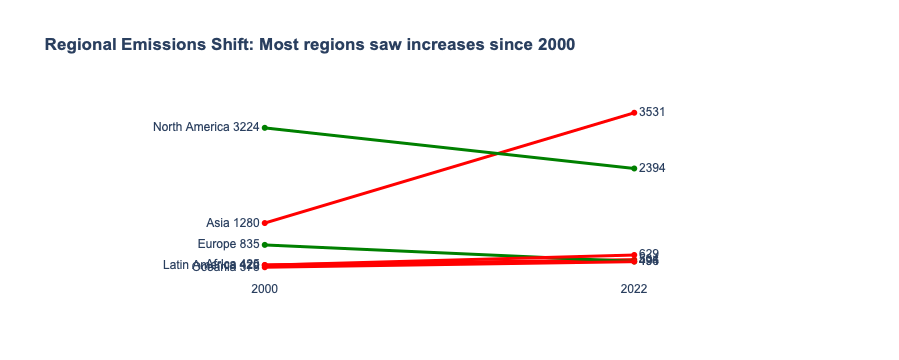

In [8]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE

df_reg = df.groupby(['Region', 'Year'])['CO2_Mt'].mean().reset_index()
df_slope = df_reg[df_reg['Year'].isin([2000, 2022])]

fig = go.Figure()

for region in df_slope['Region'].unique():
    df_r = df_slope[df_slope['Region'] == region].sort_values('Year')
    
    val_start = df_r['CO2_Mt'].iloc[0]
    val_end = df_r['CO2_Mt'].iloc[-1]
    
    line_color = "red" if val_end > val_start else "green"
    
    fig.add_trace(go.Scatter(
        x=df_r['Year'].astype(str),
        y=df_r['CO2_Mt'],
        mode='lines+markers+text',
        name=region,
        line=dict(color=line_color, width=3),
        text=[f"{region} {val_start:.0f}", f"{val_end:.0f}"],
        textposition=["middle left", "middle right"],
        showlegend=False
    ))

fig.update_layout(
    title="<b>Regional Emissions Shift: Most regions saw increases since 2000</b>",
    template='plotly_white',
    font=dict(family="Arial"),
    yaxis=dict(showticklabels=False, showgrid=False, zeroline=False),
    xaxis=dict(showgrid=False, range=[-0.5, 1.5])
)

fig.show()